# SpatialSIR3D viaABC IoC Example

This notebook demonstrates how to use the new viaABC API with an example-side adapter that injects the existing legacy `SpatialSIR3D` hooks into the framework.

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

for parent in (Path.cwd(), *Path.cwd().parents):
    src_dir = parent / "src"
    if (src_dir / "viaabc").is_dir():
        sys.path.insert(0, str(parent))
        sys.path.insert(0, str(src_dir))
        break

from viaabc import ABCConfig, IdentityEncoder, infer
from viaabc.priors import JointPrior, UniformPrior
from viaabc.runtime import Runtime

from examples.viaabc_ioc.spatial_sir3d_system import SpatialSIR3DSystem

output_dir = Path("outputs/spatial_sir3d_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

## Define System, Observation, Prior, Encoder

In [5]:
system = SpatialSIR3DSystem(
    grid_size=24,
    time_space=[1.0, 2.0, 3.0, 4.0],
    radius=3,
    seed=11,
)

true_theta = np.array([1.1, 1.2])
observed, status = system.simulate(true_theta)
assert status == 0

prior = JointPrior({
    "beta": UniformPrior(0.2, 2.0),
    "tau_I": UniformPrior(0.5, 2.2),
})

encoder = IdentityEncoder()
observed.shape

(4, 24, 24)

## Run viaABC Inference

The small particle count keeps the notebook fast. Increase `num_particles` and `max_generations` for a real experiment.

In [6]:
config = ABCConfig(
    num_particles=20,
    k=2,
    max_generations=2,
    q_threshold=0.999,
    epsilon_quantile=0.5,
    num_workers=4,
    simulation_batch_size=8,
    seed=13,
    distance="l2",
)

result = infer(
    system=system,
    prior=prior,
    encoder=encoder,
    observed=observed,
    config=config,
    runtime=Runtime.cpu(num_workers=4),
)

result.summary()

{'num_generations': 3,
 'epsilon': 29.231470108032227,
 'posterior_mean': [1.115257880420121, 1.3733109157207486],
 'credible_interval_95': [[0.8360146074326227, 1.0453558491969275],
  [1.4446690736041337, 1.728765052871928]]}

## Visualize Observation, Posterior Prediction, Particles, and Tolerance

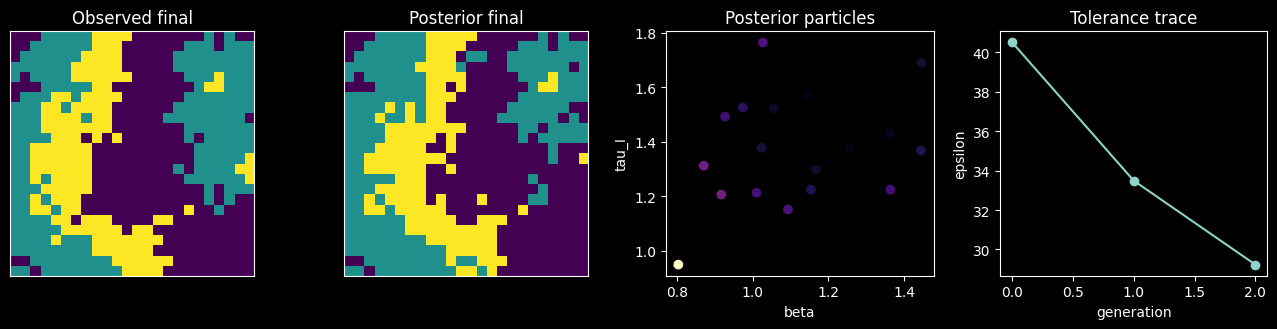

In [7]:
def sir_frame_labels(x):
    x = np.asarray(x)
    if x.ndim == 4 and x.shape[0] == 3:
        return np.argmax(x[:, -1], axis=0)
    if x.ndim == 3:
        return x[-1]
    raise ValueError(f"Unsupported SIR frame shape: {x.shape}")

posterior_theta = result.posterior_mean()
predicted, _ = system.simulate(posterior_theta)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))

axes[0].imshow(sir_frame_labels(observed), vmin=0, vmax=2, cmap="viridis")
axes[0].set_title("Observed final")

axes[1].imshow(sir_frame_labels(predicted), vmin=0, vmax=2, cmap="viridis")
axes[1].set_title("Posterior final")

axes[2].scatter(result.particles[:, 0], result.particles[:, 1], c=result.weights, cmap="magma")
axes[2].set_xlabel("beta")
axes[2].set_ylabel("tau_I")
axes[2].set_title("Posterior particles")

axes[3].plot([generation["epsilon"] for generation in result.generations], marker="o")
axes[3].set_xlabel("generation")
axes[3].set_ylabel("epsilon")
axes[3].set_title("Tolerance trace")

for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
fig.savefig(output_dir / "spatial_sir3d_notebook_visualization.png", dpi=160)
plt.show()

## Save Result

In [ ]:
result.save(output_dir)
list(output_dir.iterdir())